# Telco Customer Churn — Exploratory Analysis and Churn Prediction


The telecom industry is characterized by intense competition and a largely homogeneous set of core services, which makes customer churn a critical challenge. Telecom providers engage in tight price wars, compete with differentiated offerings, and offer aggressive retention incentives. Yet, the ease of switching telecom operators means customer loyalty is fragile and acquiring new customers costly. This project analyzes a telecom customer dataset to identify the key drivers of churn and builds predictive models (Logistic Regression and Random Forest) to estimate churn risk at the individual customer level, with the goal of informing targeted retention strategies.

# 1. Import Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")



# 2. Load Dataset

In [2]:

raw_data = pd.read_csv("data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

raw_data.shape


(7043, 21)

# 3. Data Understanding

In [3]:
raw_data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [4]:
raw_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [5]:
raw_data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [6]:
raw_data.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
total_duplicates = raw_data.duplicated().sum()
print(f"Duplicated Rows: {total_duplicates}")


Duplicated Rows: 0


# 4. Data Cleaning

In [8]:

raw_data['TotalCharges'] = (raw_data['TotalCharges']).str.strip() ## from string to float
raw_data['TotalCharges'] = pd.to_numeric(raw_data['TotalCharges'], errors='coerce')

print(f"Rows with missing TotalCharges after coercion: {raw_data['TotalCharges'].isna().sum()}")
print(raw_data.loc[raw_data['TotalCharges'].isna(), 'tenure'].value_counts())

Rows with missing TotalCharges after coercion: 11
tenure
0    11
Name: count, dtype: int64


In [9]:
raw_data['TotalCharges'] = (
    pd.to_numeric(raw_data['TotalCharges'], errors='coerce')
)

raw_data['TotalCharges'] = raw_data['TotalCharges'].fillna(0)

In [10]:
# Standardize service-related categorical values

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
                     'TechSupport', 'StreamingTV', 'StreamingMovies']

for col in service_cols:
    raw_data[col] = raw_data[col].replace('No internet service', 'No')


raw_data['MultipleLines'] = raw_data['MultipleLines'].replace('No phone service', 'No')



In [11]:
raw_data['SeniorCitizenCateg'] = raw_data['SeniorCitizen'].map({0: 'No', 1: 'Yes'})

# 5. Exploratory Data Analysis

## 5.1 Categorical Features 

In [12]:
## crosstab everything in the columns list
def churn_crosstab_loop(raw_data,columns):
    return {
        col: pd.crosstab(raw_data['Churn'], raw_data[col], normalize='columns')
        for col in columns
    }





cat_columns = ['Contract', 'PaymentMethod', 'TechSupport', 'SeniorCitizenCateg', 'PhoneService',
            'MultipleLines','InternetService','OnlineSecurity', 'OnlineBackup','StreamingTV','StreamingMovies',
            'Dependents','DeviceProtection','Partner']


cat_result = churn_crosstab_loop(raw_data, cat_columns)
cat_result['Contract']

for col, table in cat_result.items():
    print(f"\n===== Churn vs {col} =====")
    print(table)




===== Churn vs Contract =====
Contract  Month-to-month  One year  Two year
Churn                                       
No              0.572903  0.887305  0.971681
Yes             0.427097  0.112695  0.028319

===== Churn vs PaymentMethod =====
PaymentMethod  Bank transfer (automatic)  Credit card (automatic)  \
Churn                                                               
No                              0.832902                 0.847569   
Yes                             0.167098                 0.152431   

PaymentMethod  Electronic check  Mailed check  
Churn                                          
No                     0.547146      0.808933  
Yes                    0.452854      0.191067  

===== Churn vs TechSupport =====
TechSupport        No       Yes
Churn                          
No           0.688138  0.848337
Yes          0.311862  0.151663

===== Churn vs SeniorCitizenCateg =====
SeniorCitizenCateg        No       Yes
Churn                                 
No 

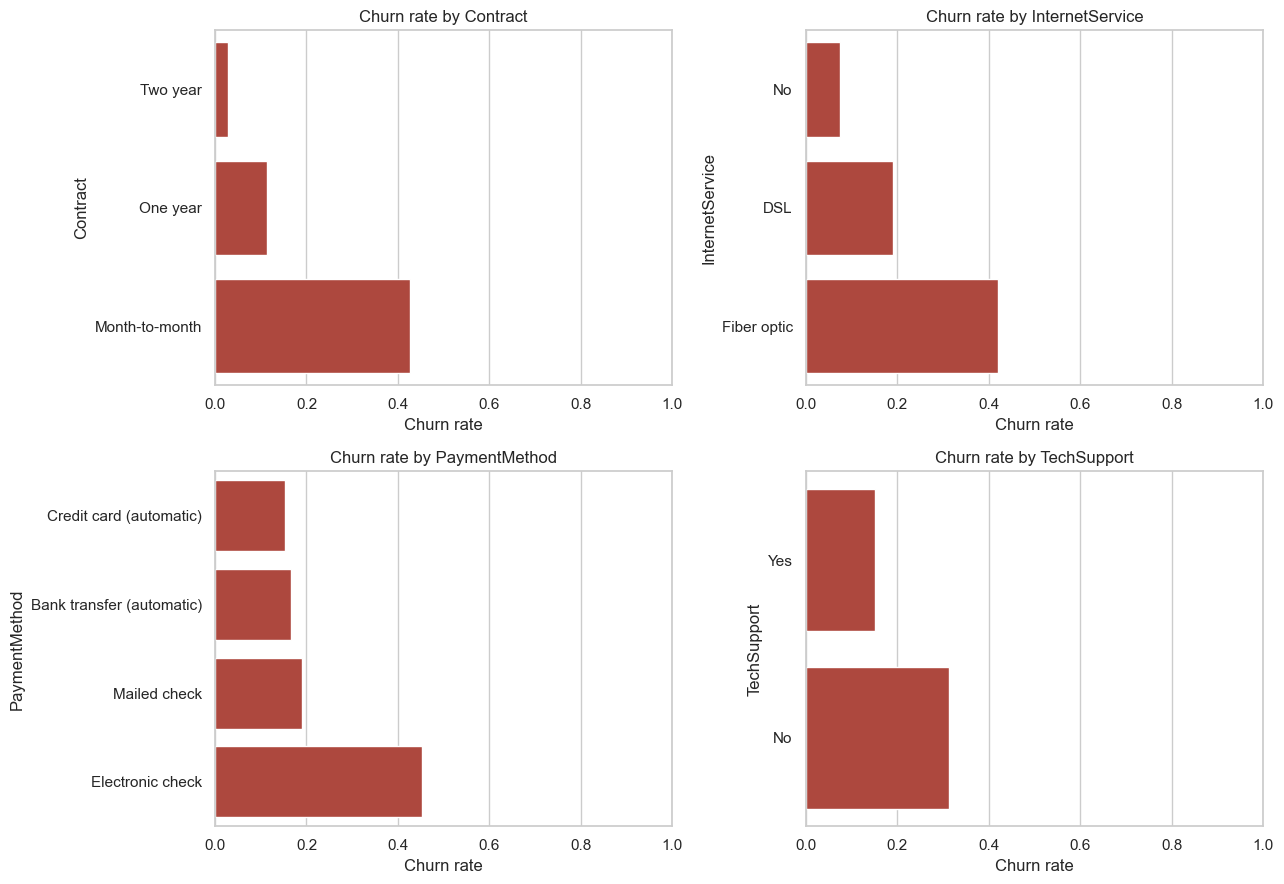

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
highlight_cols = ['Contract', 'InternetService', 'PaymentMethod', 'TechSupport']

for ax, col in zip(axes.flat, highlight_cols):
    churn_rate = raw_data.groupby(col)['Churn'].apply(lambda s: (s == 'Yes').mean()).sort_values()
    sns.barplot(x=churn_rate.values, y=churn_rate.index, ax=ax, color='#c0392b')
    ax.set_title(f'Churn rate by {col}')
    ax.set_xlabel('Churn rate')
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 5.2 Numerical Features

In [14]:


def churn_numeric_binning(raw_data, col, bins=5):
    raw_data[f'{col}_bin'] = pd.qcut(raw_data[col], q=bins, duplicates='drop')
    
    return pd.crosstab(raw_data['Churn'], raw_data[f'{col}_bin'], normalize='columns')



numerical_cols = ['tenure','MonthlyCharges','TotalCharges']

numerical_results = {
    col : churn_numeric_binning(raw_data, col)
    for col in numerical_cols
}

for col, table in numerical_results.items():
    print(f"\n ==== Churn vs {col}(Binned) ====")
    print(table)



 ==== Churn vs tenure(Binned) ====
tenure_bin  (-0.001, 6.0]  (6.0, 20.0]  (20.0, 40.0]  (40.0, 60.0]  \
Churn                                                                
No               0.470628     0.665712      0.776278      0.844444   
Yes              0.529372     0.334288      0.223722      0.155556   

tenure_bin  (60.0, 72.0]  
Churn                     
No              0.933902  
Yes             0.066098  

 ==== Churn vs MonthlyCharges(Binned) ====
MonthlyCharges_bin  (18.249, 25.05]  (25.05, 58.83]  (58.83, 79.1]  \
Churn                                                                
No                         0.908451        0.750179       0.702339   
Yes                        0.091549        0.249821       0.297661   

MonthlyCharges_bin  (79.1, 94.25]  (94.25, 118.75]  
Churn                                               
No                       0.638948         0.671875  
Yes                      0.361052         0.328125  

 ==== Churn vs TotalCharges(Binned) =

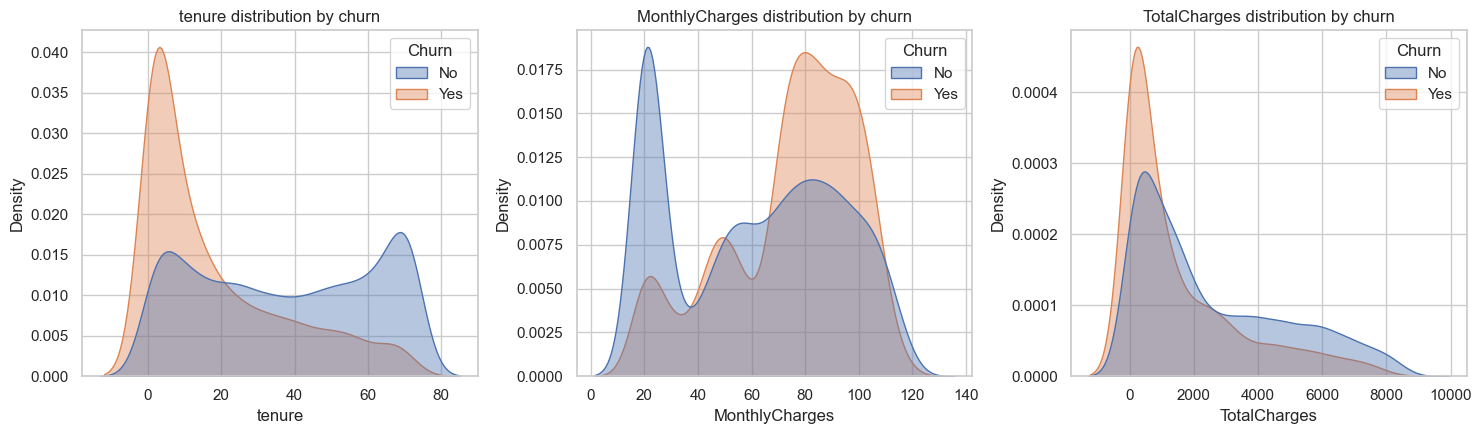

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, col in zip(axes, numerical_cols):
    sns.kdeplot(data=raw_data, x=col, hue='Churn', fill=True, common_norm=False, alpha=0.4, ax=ax)
    ax.set_title(f'{col} distribution by churn')

plt.tight_layout()
plt.show()

## 5.3 Multivariate Analysis

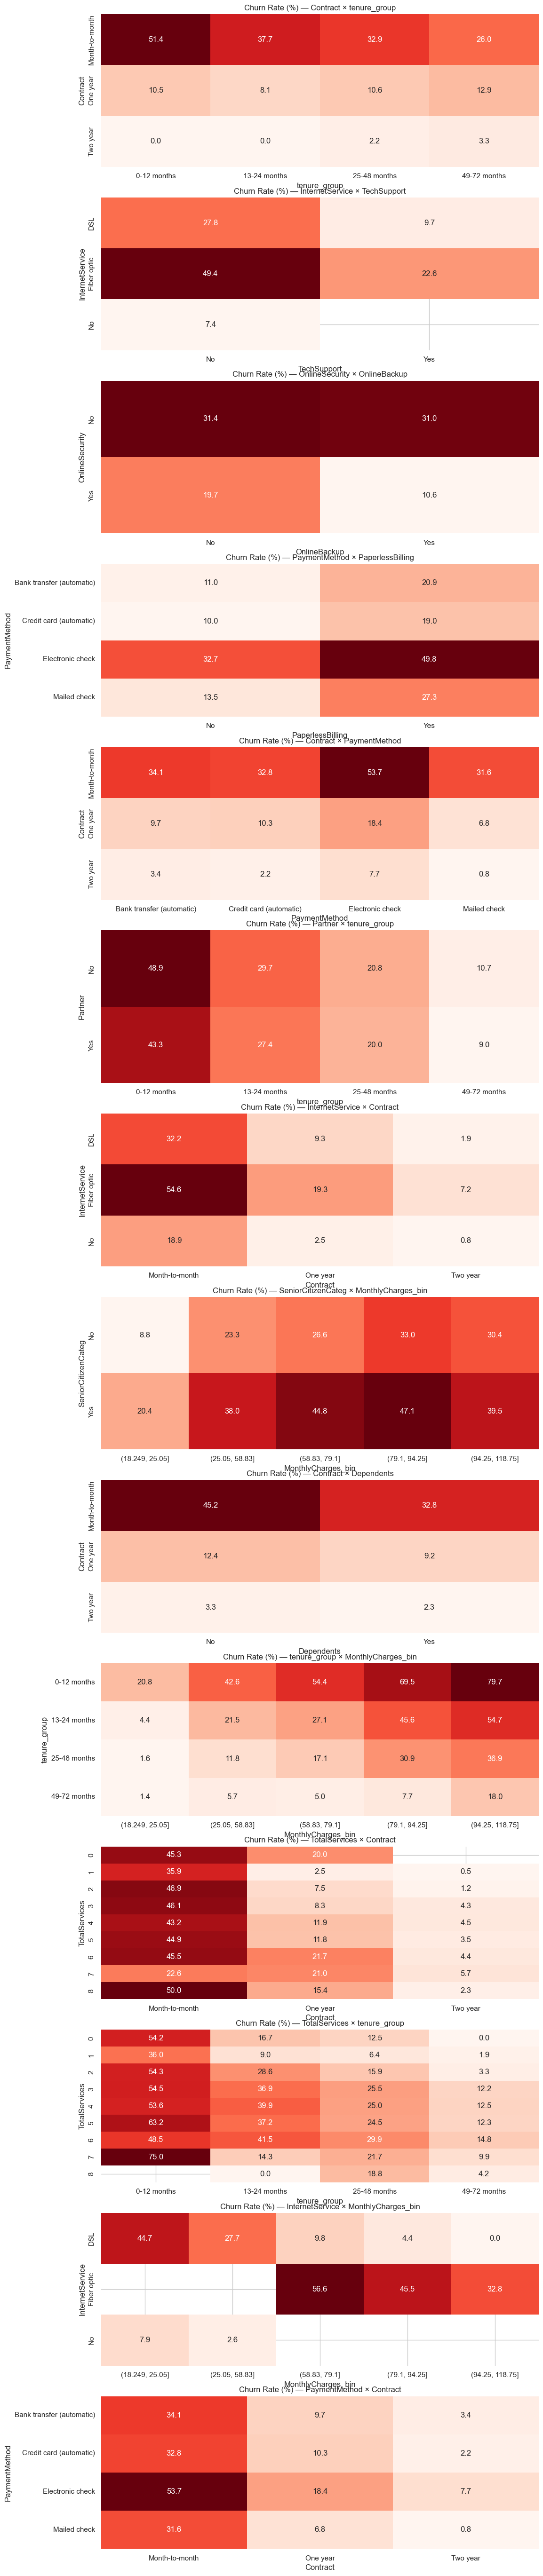

In [32]:
variable_pairs = [
    ('Contract', 'tenure_group'), #contract and commitment
    ('InternetService', 'TechSupport'), #stickiness
    ('OnlineSecurity', 'OnlineBackup'), #stickiness
    ('PaymentMethod', 'PaperlessBilling'), #billing and payment friction
    ('Contract', 'PaymentMethod'), #contract and commitment
    ('Partner', 'tenure_group'), #demographics
    ('InternetService', 'Contract'), #contract and commitment
    ('SeniorCitizenCateg', 'MonthlyCharges_bin'), #demographics #pricing
    ('Contract', 'Dependents'),   #demographics
    ('tenure_group', 'MonthlyCharges_bin'),#pricing
    ('TotalServices', 'Contract'), #stickiness                           
    ('TotalServices', 'tenure_group'), #stickiness
    ('InternetService', 'MonthlyCharges_bin'), #pricing  #stickiness
    ('PaymentMethod', 'Contract'),     #billing and payment friction
]

fig, axes = plt.subplots(nrows=len(variable_pairs), ncols=1, figsize=(12, len(variable_pairs) * 5))

for i, (col1, col2) in enumerate(variable_pairs):
    multivariate_ct = pd.crosstab(raw_data[col1], raw_data[col2],
                     values=(raw_data['Churn'] == 'Yes').astype(int),
                     aggfunc='mean') * 100

    sns.heatmap(multivariate_ct, annot=True, fmt='.1f', cmap='Reds',
                ax=axes[i], cbar=False)
    axes[i].set_title(f'Churn Rate (%) — {col1} × {col2}')

# 6. Feature Engineering

In [17]:

raw_data['Monthlycharges_group'] = pd.cut(
    raw_data['MonthlyCharges'],
    bins=[0, 30, 60, 90, 120,],
    labels=[
        '0-30$',
        '31-60$',
        '61-90$',
        '91-120$'
        ]
)



raw_data['tenure_group'] = pd.cut(
    raw_data['tenure'],
    bins=[0, 12, 24, 48, 72],
    labels=[
        '0-12 months', 
        '13-24 months', 
        '25-48 months', 
        '49-72 months'
    ],
    include_lowest=True
)

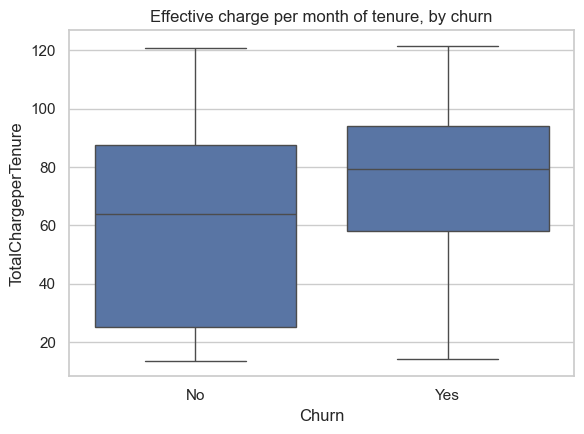

In [18]:
raw_data['TotalChargeperTenure'] = np.where(
    raw_data['tenure'] == 0,
    raw_data['MonthlyCharges'],
    raw_data['TotalCharges'] / raw_data['tenure']
)

fig, ax = plt.subplots(figsize=(6, 4.5))
sns.boxplot(data=raw_data, x='Churn', y='TotalChargeperTenure', ax=ax)
ax.set_title('Effective charge per month of tenure, by churn')
plt.tight_layout()
plt.show()

In [19]:
## total charges per tenure

raw_data["TotalChargeperTenure"] = raw_data["TotalCharges"] / raw_data['tenure']
print(raw_data['TotalChargeperTenure'])

0        29.850000
1        55.573529
2        54.075000
3        40.905556
4        75.825000
           ...    
7038     82.937500
7039    102.262500
7040     31.495455
7041     76.650000
7042    103.704545
Name: TotalChargeperTenure, Length: 7043, dtype: float64


In [20]:
raw_data["TotalChargeperTenure"] = np.where(
    raw_data['tenure'] == 0,
    raw_data['MonthlyCharges'],
    raw_data["TotalCharges"] / raw_data['tenure']
)

In [21]:
print(raw_data)

      customerID  gender  SeniorCitizen Partner Dependents  tenure  \
0     7590-VHVEG  Female              0     Yes         No       1   
1     5575-GNVDE    Male              0      No         No      34   
2     3668-QPYBK    Male              0      No         No       2   
3     7795-CFOCW    Male              0      No         No      45   
4     9237-HQITU  Female              0      No         No       2   
...          ...     ...            ...     ...        ...     ...   
7038  6840-RESVB    Male              0     Yes        Yes      24   
7039  2234-XADUH  Female              0     Yes        Yes      72   
7040  4801-JZAZL  Female              0     Yes        Yes      11   
7041  8361-LTMKD    Male              1     Yes         No       4   
7042  3186-AJIEK    Male              0      No         No      66   

     PhoneService MultipleLines InternetService OnlineSecurity  ...  \
0              No            No             DSL             No  ...   
1             Yes

In [22]:
## Total Services
# Counts all subscribed services, including phone and internet-related services
service_cols = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

raw_data['TotalServices'] = (
    raw_data[service_cols].apply(
        lambda x: (x == 'Yes').sum(), axis=1
    )
)

In [23]:
# Total Engagement
# Counts optional value-added services such as security, backup, device protection, technical support, and streaming.
engagement_cols = [
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]

raw_data['EngagementScore'] = (
    raw_data[engagement_cols]
    .apply(lambda x: (x == 'Yes').sum(), axis=1)
    
)

## 6. Synthetic Geographic Enrichment
Because the source dataset does not contain geographic information, customer boroughs were synthetically assigned using population- and population-density-informed probabilities based on NYC borough-level data. These assignments are intended solely to support exploratory geographic analysis and do not represent actual customer locations.

In [24]:
borough_data = pd.DataFrame({
    'Borough': [
        'Brooklyn',
        'Queens',
        'Manhattan',
        'The Bronx',
        'Staten Island'
    ],

    'Population': [
        2736074,
        2405464,
        1694251,
        1472654,
        495747
    ],

    'PopulationDensity': [
        39437.8,
        22124.5,
        74781.6,
        34920.2,
        8618.1
    ]
})


In [25]:
borough_data['PopulationShare'] = (
    borough_data['Population'] /
    borough_data['Population'].sum()
)

borough_data['DensityShare'] = (
    borough_data['PopulationDensity'] /
    borough_data['PopulationDensity'].sum()
)

borough_data['Weight'] = (
    0.70 * borough_data['PopulationShare'] +
    0.30 * borough_data['DensityShare']
)



In [26]:
borough_data

,Borough,Population,PopulationDensity,PopulationShare,DensityShare,Weight
0,Brooklyn,2736074,39437.8,0.310770,0.219242,0.283311
1,Queens,2405464,22124.5,0.273218,0.122994,0.228151
2,Manhattan,1694251,74781.6,0.192437,0.415725,0.259423
3,The Bronx,1472654,34920.2,0.167267,0.194128,0.175326
4,Staten Island,495747,8618.1,0.056308,0.047910,0.053789


In [27]:
borough_data['Weight'].sum()

np.float64(0.9999999999999998)

In [28]:
borough_data[
    ['Borough', 'Population', 'PopulationDensity', 'Weight']
].sort_values(
    'Weight',
    ascending=False
)

,Borough,Population,PopulationDensity,Weight
0,Brooklyn,2736074,39437.8,0.283311
2,Manhattan,1694251,74781.6,0.259423
1,Queens,2405464,22124.5,0.228151
3,The Bronx,1472654,34920.2,0.175326
4,Staten Island,495747,8618.1,0.053789


In [29]:
np.random.seed(42)

raw_data['Borough'] = np.random.choice(
    borough_data['Borough'],
    size=len(raw_data),
    p=borough_data['Weight']
)

In [30]:
raw_data['Borough'].value_counts()

Borough
Brooklyn         2036
Manhattan        1807
Queens           1598
The Bronx        1215
Staten Island     387
Name: count, dtype: int64

In [31]:
actual_distribution = (
    raw_data['Borough']
    .value_counts(normalize=True)
    .rename('ActualShare')
    .reset_index()
)

actual_distribution.columns = ['Borough', 'ActualShare']

actual_distribution = actual_distribution.merge(
    borough_data[['Borough', 'Weight']],
    on='Borough'
)

actual_distribution['ExpectedShare'] = actual_distribution['Weight']

actual_distribution

,Borough,ActualShare,Weight,ExpectedShare
0,Brooklyn,0.289081,0.283311,0.283311
1,Manhattan,0.256567,0.259423,0.259423
2,Queens,0.226892,0.228151,0.228151
3,The Bronx,0.172512,0.175326,0.175326
4,Staten Island,0.054948,0.053789,0.053789


# 7. Multicollinearity Analysis
Checking multicollinearity of numerical data

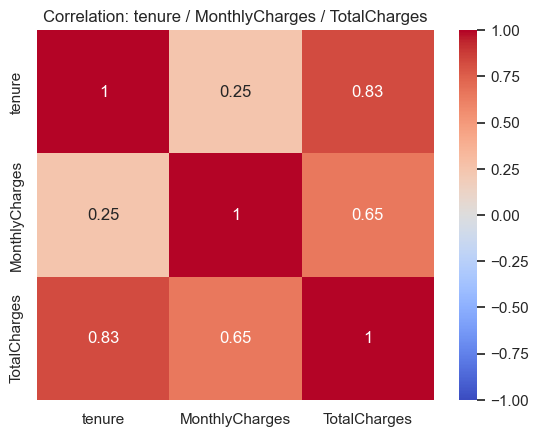

,tenure,MonthlyCharges,TotalCharges
tenure,1.000000,0.247900,0.826178
MonthlyCharges,0.247900,1.000000,0.651174
TotalCharges,0.826178,0.651174,1.000000


In [33]:
corr = raw_data[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: tenure / MonthlyCharges / TotalCharges')
plt.show()
corr

# 8. Model

In [34]:
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score,
                              roc_auc_score, roc_curve, precision_recall_curve, RocCurveDisplay)

# 8.1 Data Preparation

In [35]:


eda_only_cols = [
    'Churn', 
    'customerID',
    'Monthlycharges_group', 
    'tenure_group',
    'SeniorCitizenCateg', 
    'TotalChargeperTenure',
    'TotalCharges', 
    'tenure_bin',
    'MonthlyCharges_bin',
    'TotalCharges_bin',
    'Borough',
    'TotalServices',
    'EngagementScore'
]



X = raw_data.drop(columns=eda_only_cols)
y = raw_data['Churn'].map({
    'Yes': 1,
    'No':0
})

numeric_features = ['tenure', 'MonthlyCharges', 'SeniorCitizen']
categorical_features = [c for c in X.columns if c not in numeric_features]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical_features),
])

In [36]:
raw_data['TotalCharges'] = pd.to_numeric(raw_data['TotalCharges'], errors='coerce')
raw_data['TotalCharges'] = raw_data['TotalCharges'].fillna(0)  # new customers, 0 makes sense here

#  Variance Inflation Factor - VIF

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

vif_X = pd.get_dummies(X, drop_first=True).astype(float)
vif_X = sm.add_constant(vif_X)

vif_table = pd.DataFrame({
    'feature': vif_X.columns,
    'VIF': [variance_inflation_factor(vif_X.values, i) for i in range(vif_X.shape[1])]
})

vif_table = vif_table[vif_table['feature'] != 'const'].sort_values('VIF', ascending=False)
vif_table.head(15)

,feature,VIF
3,MonthlyCharges,862.660077
9,InternetService_Fiber optic,148.263291
10,InternetService_No,104.133133
7,PhoneService_Yes,34.859709
16,StreamingMovies_Yes,24.105011
15,StreamingTV_Yes,24.052938
8,MultipleLines_Yes,7.270912
13,DeviceProtection_Yes,6.904175
12,OnlineBackup_Yes,6.748448
14,TechSupport_Yes,6.451603


# 8.2 Logistic Regression

In [38]:
logreg_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
])

logreg_pipe.fit(X_train, y_train)
y_pred_lr = logreg_pipe.predict(X_test)
y_proba_lr = logreg_pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_lr))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lr))

Accuracy: 0.7402413058907026
ROC-AUC: 0.8387713451652071

Confusion Matrix:
 [[754 281]
 [ 85 289]]

Classification Report:
               precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.77      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409



# 8.3 Random Forest

In [39]:
rf_pipe = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                      random_state=42, n_jobs=-1)),
])

rf_pipe.fit(X_train, y_train)
y_pred_rf = rf_pipe.predict(X_test)
y_proba_rf = rf_pipe.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

Accuracy: 0.7849538679914834
ROC-AUC: 0.8191208762820016

Confusion Matrix:
 [[925 110]
 [193 181]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.62      0.48      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.78      1409



# 9. Model Evaluation

## 9.1 ROC Curve

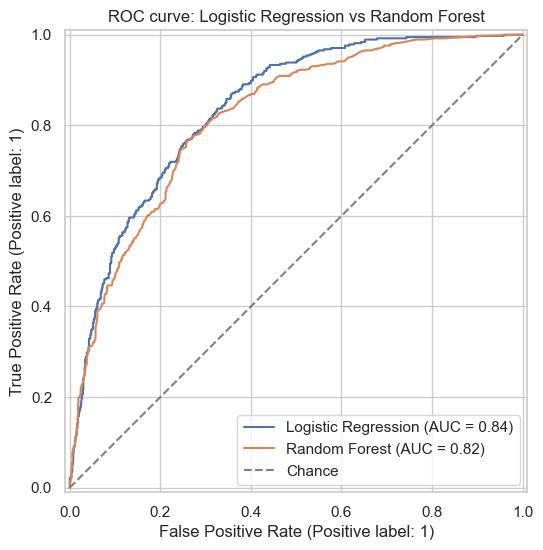

In [40]:
fig, ax = plt.subplots(figsize=(6, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
ax.set_title('ROC curve: Logistic Regression vs Random Forest')
ax.legend()
plt.show()

# 9.2 Precision-recall Tradeoff

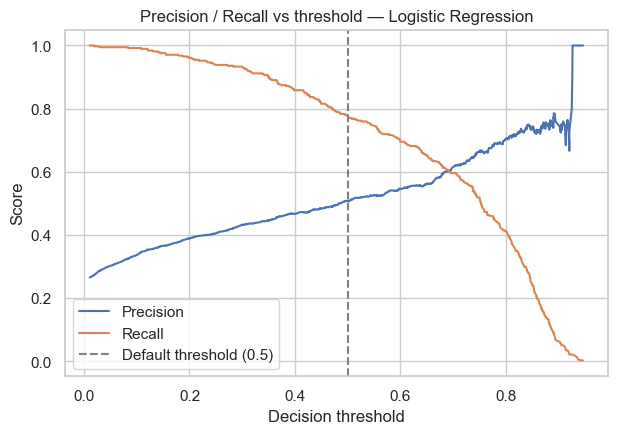

In [41]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba_lr)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(thresholds, precision[:-1], label='Precision')
ax.plot(thresholds, recall[:-1], label='Recall')
ax.axvline(0.5, linestyle='--', color='gray', label='Default threshold (0.5)')
ax.set_xlabel('Decision threshold')
ax.set_ylabel('Score')
ax.set_title('Precision / Recall vs threshold — Logistic Regression')
ax.legend()
plt.show()

# 9.3 Logistic Regression Coefficients

In [42]:
feature_names = logreg_pipe.named_steps['preprocess'].get_feature_names_out()
coefs = logreg_pipe.named_steps['model'].coef_[0]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefs
}).sort_values(by='Coefficient', ascending=False)


In [43]:

feature_importance.head(10)

,Feature,Coefficient
8,cat__InternetService_Fiber optic,1.122697
20,cat__PaymentMethod_Electronic check,0.399563
15,cat__StreamingMovies_Yes,0.393957
14,cat__StreamingTV_Yes,0.369890
18,cat__PaperlessBilling_Yes,0.334435
7,cat__MultipleLines_Yes,0.323463
21,cat__PaymentMethod_Mailed check,0.084455
2,num__SeniorCitizen,0.055945
12,cat__DeviceProtection_Yes,0.039050
3,cat__gender_Male,0.037466


In [44]:
feature_importance.tail(10)

,Feature,Coefficient
11,cat__OnlineBackup_Yes,-0.071362
6,cat__PhoneService_Yes,-0.237553
5,cat__Dependents_Yes,-0.239776
1,num__MonthlyCharges,-0.265358
13,cat__TechSupport_Yes,-0.273456
10,cat__OnlineSecurity_Yes,-0.343438
16,cat__Contract_One year,-0.722221
0,num__tenure,-0.758241
9,cat__InternetService_No,-1.051911
17,cat__Contract_Two year,-1.409983


# 10. Cross-Validation

In [45]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_accuracies, fold_churn_recalls, fold_aucs = [], [], []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y), start=1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    fold_pipe = Pipeline(steps=[
        ('preprocess', preprocessor),
        ('model', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ])
    fold_pipe.fit(X_tr, y_tr)
    fold_pred = fold_pipe.predict(X_te)
    fold_proba = fold_pipe.predict_proba(X_te)[:, 1]

    acc = accuracy_score(y_te, fold_pred)
    auc = roc_auc_score(y_te, fold_proba)
    churn_recall = classification_report(y_te, fold_pred, output_dict=True)['1']['recall']

    fold_accuracies.append(acc)
    fold_aucs.append(auc)
    fold_churn_recalls.append(churn_recall)
    print(f"Fold {fold}: accuracy={acc:.4f}  auc={auc:.4f}  churn_recall={churn_recall:.4f}")

print(f"\nMean accuracy:     {np.mean(fold_accuracies):.4f} (+/- {np.std(fold_accuracies):.4f})")
print(f"Mean ROC-AUC:       {np.mean(fold_aucs):.4f} (+/- {np.std(fold_aucs):.4f})")
print(f"Mean churn recall:  {np.mean(fold_churn_recalls):.4f} (+/- {np.std(fold_churn_recalls):.4f})")

Fold 1: accuracy=0.7594  auc=0.8539  churn_recall=0.8048
Fold 2: accuracy=0.7480  auc=0.8432  churn_recall=0.8182
Fold 3: accuracy=0.7601  auc=0.8616  churn_recall=0.8102
Fold 4: accuracy=0.7365  auc=0.8232  churn_recall=0.7587
Fold 5: accuracy=0.7443  auc=0.8337  churn_recall=0.7781

Mean accuracy:     0.7497 (+/- 0.0090)
Mean ROC-AUC:       0.8431 (+/- 0.0137)
Mean churn recall:  0.7940 (+/- 0.0222)


# 10.1 Financial Impact of Churn

In [46]:
# Financial Impact of Churn


avg_monthly_charge = raw_data['MonthlyCharges'].mean()
churned_customers = raw_data[raw_data['Churn'] == 'Yes']
n_churned = len(churned_customers)
monthly_revenue_at_risk = churned_customers['MonthlyCharges'].sum()
annual_revenue_at_risk = monthly_revenue_at_risk * 12

print(f"Churned customers: {n_churned} ({n_churned/len(raw_data):.1%} of customer base)")
print(f"Monthly revenue at risk: ${monthly_revenue_at_risk:,.0f}")
print(f"Annualized revenue at risk: ${annual_revenue_at_risk:,.0f}")



Churned customers: 1869 (26.5% of customer base)
Monthly revenue at risk: $139,131
Annualized revenue at risk: $1,669,570


In [47]:
# Customer Lifetime Value (CLV)
## to account for CLV,  average monthly charge x average tenure, by contract is used as a proxy

clv_by_contract = raw_data.groupby('Contract').apply(
    lambda d: d['MonthlyCharges'].mean() * d['tenure'].mean()
).rename('CLV_proxy ($)').sort_values()

print("\nCLV proxy ($) by contract type (avg MonthlyCharges x avg tenure):")
print(clv_by_contract.round(0))




CLV proxy ($) by contract type (avg MonthlyCharges x avg tenure):
Contract
Month-to-month    1198.0
One year          2735.0
Two year          3448.0
Name: CLV_proxy ($), dtype: float64


In [48]:
# Cost and benefit analysis of model choice: Logistic Regression vs. Random Forest
# assumes a 50$ for retention offer cost 
# assumes 25% of customers who are at risk of churn are actually saved

avg_clv = raw_data['MonthlyCharges'].mean() * raw_data['tenure'].mean()  
retention_offer_cost = 50        
retention_success_rate = 0.25    

def model_financials(y_true, y_pred, name):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    revenue_saved = tp * retention_success_rate * avg_clv
    offer_cost = (tp + fp) * retention_offer_cost
    revenue_lost_to_misses = fn * avg_clv
    net_impact = revenue_saved - offer_cost

    print(f"\n{name}")
    print(f"  Customers flagged as churners (TP+FP): {tp + fp}")
    print(f"  Churners actually saved (est.):        {tp * retention_success_rate:.0f}")
    print(f"  Revenue saved (est.):                  ${revenue_saved:,.0f}")
    print(f"  Retention campaign cost:                ${offer_cost:,.0f}")
    print(f"  Net financial impact:                   ${net_impact:,.0f}")
    print(f"  Revenue still lost to missed churners (FN): ${revenue_lost_to_misses:,.0f}")
    return net_impact

net_lr = model_financials(y_test, y_pred_lr, "Logistic Regression")
net_rf = model_financials(y_test, y_pred_rf, "Random Forest")

print(f"\nLogistic Regression nets ${net_lr - net_rf:,.0f} more value than Random Forest on this test set,")
print("driven almost entirely by its higher recall -- it misses far fewer churners,")
print("and each missed churner (a full lost CLV) is far more costly than an extra $50 retention offer.")



Logistic Regression
  Customers flagged as churners (TP+FP): 570
  Churners actually saved (est.):        72
  Revenue saved (est.):                  $151,466
  Retention campaign cost:                $28,500
  Net financial impact:                   $122,966
  Revenue still lost to missed churners (FN): $178,195

Random Forest
  Customers flagged as churners (TP+FP): 291
  Churners actually saved (est.):        45
  Revenue saved (est.):                  $94,863
  Retention campaign cost:                $14,550
  Net financial impact:                   $80,313
  Revenue still lost to missed churners (FN): $404,607

Logistic Regression nets $42,653 more value than Random Forest on this test set,
driven almost entirely by its higher recall -- it misses far fewer churners,
and each missed churner (a full lost CLV) is far more costly than an extra $50 retention offer.


# 11. Conclusion




The  data analysis showed that churn is concentrated on newer, flexible, and low commitment customer segments. Bivariate analysis points to  contract types as the single strongest driver of churn. Month-to-month customers churn at 42.7% overall, compared to one-year and two year contracts with 11.3% and 2.8%, respectively. 

Moreover, further analysis shows that no single variable can be isolated as the sole driving factor for churn. Multivariate EDA shows that a combination of contract with other risk factors produces more riskier segments. Fiber-optic + month-to-month churns at 54.6%, more than double DSL + month-to-month and vastly higher than any two-year combination (≤7.2%). Additionally, Fiber customers without tech support churn at 49.4%, dropping to 22.6% with support — consistent with the regression, where fiber internet (+1.12) is the largest churn-increasing coefficient in the entire model, while tech support (−0.27) and online security (−0.34) both push in the opposite direction. Additional bundled services (security, backup, protection, streaming) barely move churn among month-to-month customers, but are associated with lower churn among one- and two-year customers — suggesting bundling reinforces retention mainly after a customer has already committed to a longer contract, rather than substituting for one.

The logistic regression coeffifients validate these findings. In the model, two-year contract (−1.41) and one-year contract (−0.72) presents the strongest reduction effect with churn, ahead of tenure (-0.76). Tenure matters, but mainly as a proxy for commitment — even within month-to-month customers, churn falls from 51.4% (0–12 months) to 26.0% (49–72 months) with tenure, but never approaches the near-zero rates seen in longer contracts at any tenure level. In other words, the contract itself does more to retain a customer than tenure alone.

The model is stable and fit for identifying at-risk customers, not just describing them. Logistic Regression achieved 74.0% accuracy and a 0.839 ROC-AUC on the held-out test set, correctly identifying 77% of actual churners (recall). Random Forest scored higher on accuracy (78.5%) and precision (0.62 vs. 0.51), but caught meaningfully fewer churners (48% recall vs. 77%). Because the cost of missing a churner (a lost customer) generally outweighs the cost of a false alarm (an unnecessary retention offer), Logistic Regression with balanced class weighting is the more practical choice for this use case, despite its lower headline accuracy. Five-fold cross-validation confirmed this performance is stable rather than a lucky split: mean accuracy 74.97% (±0.90%), mean ROC-AUC 0.843 (±1.4%), and mean churn recall 79.4% (±2.2%) — tight variance across folds.


Churn also has a direct revenue cost. The ~1,869 churned customers in this dataset pay an average of $64.76 a month, which works out to roughly $121K in monthly revenue at risk or about $1.45M annually. Contract type also reflects lifetime value, not just churn risk; two-year contract customers are worth more over in their lifetime than month-to-month customers on a MonthllyCharges x average tenure basis. This means that migrating customers to a longer contract does not only reduce churn risk but also increases how much that customer is worth. 

The choice of model has a financial cost too. Using a $50 retention offer and a 25% save rate as rough assumptions, Logistic Regession's confusion matrix shows (289 TP / 281 FP / 85 FN) nets around $123K in estimated value compared to the Random Forest's $80k (181 TP / 110 FP / 193 FN). This is a difference of $40K on the test set alone. The gap comes from Random Forest missing 193 churned customers against Logistic Regression's 85. Each missed churned customer costs a full CLV (~$2,096), which is far more expensive than the unnecessary $50 retention offer. This is the same recall-over-precision argument from earlier,  just in monetary terms.


The most available option for business is to migrate month-to-month contract customers onto one- or two-year contracts, since contract length suppresses churn risk even among customers who carry other risk variables (fiber internet, electronic check payment, low service adoption). This could be paired with targeted retention offers ie., contract-upgrade incentives, bundled tech support/security add-ons, or a nudge toward autopay — specifically for the segment identified by the model as highest-risk: new, month-to-month, fiber-optic customers paying by electronic check with few add-on services.


# Connecting to PowerBI

In [ ]:
# Create a clean Power BI export dataset
powerbi_data = raw_data.drop(
    columns=[
        'tenure_bin',
        'MonthlyCharges_bin',
        'TotalCharges_bin'
    ],
    errors='ignore'
)

# Export as CSV
powerbi_data.to_csv(
    'Telco_Churn_PowerBI.csv',
    index=False
)

print(powerbi_data.shape)

powerbi_data.head()

In [ ]:
powerbi_data.info()
powerbi_data.isnull().sum()
powerbi_data.duplicated().sum()

In [ ]:
print(powerbi_data.columns.tolist())